In [1]:
import os, sys, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm

sys.path.insert(0, '/Users/faenegoro/Documents/Neuroimaging/BrainOmni')
sys.path.insert(0, '/Users/faenegoro/Documents/Neuroimaging/meg_ad_project')
from brainomni.model import BrainOmni
from src.preprocessing import preprocess_subject, FS_TARGET, SEGMENT_SECS

device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print('Device:', device)

W0623 22:30:37.176000 64005 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.


Device: mps


In [2]:
# Load BrainOmni-tiny and freeze all layers
CKPT_PATH = '/Users/faenegoro/Documents/Neuroimaging/BrainOmni/ckpt_collection/tiny'

with open(os.path.join(CKPT_PATH, 'model_cfg.json')) as f:
    model_config = json.load(f)

model = BrainOmni(**model_config)
checkpoint = torch.load(os.path.join(CKPT_PATH, 'BrainOmni.pt'), map_location='cpu', weights_only=True)
model.load_state_dict(checkpoint, strict=False)

# Freeze everything
for param in model.parameters():
    param.requires_grad = False

model = model.to(device)
model.eval()

# encode() uses blocks[:-1] = blocks 0-10
# We freeze blocks 0-8, unfreeze blocks 9-10
N_FROZEN = 9
for block in list(model.blocks)[N_FROZEN:-1]:
    for param in block.parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Trainable: 1,316,352 / 13,475,042 (9.8%)


In [3]:
# Build labels
DATA_DIR = '/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/data/meg_mri'
files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('_meg_rest_60sec.mat')])

labels_dict = {}
for f in files:
    sid = f.split('_')[0]
    labels_dict[sid] = 0 if int(sid[4:]) <= 70 else 1

subject_ids = [f.split('_')[0] for f in files]
labels = np.array([labels_dict[sid] for sid in subject_ids])

print(f'Subjects: {len(labels)} | Controls: {(labels==0).sum()} | AD: {(labels==1).sum()}')

Subjects: 148 | Controls: 70 | AD: 78


In [4]:
# Preprocess all subjects and store in memory
SEGMENT_LEN = SEGMENT_SECS * FS_TARGET  # 7680

all_seg1 = []  # (271, 7680) per subject
all_seg2 = []
all_pos  = []
all_st   = []

for filename in tqdm(files, desc='Preprocessing'):
    mat_path = os.path.join(DATA_DIR, filename)
    signal, pos, sensor_type = preprocess_subject(mat_path)
    all_seg1.append(signal[:, :SEGMENT_LEN])
    all_seg2.append(signal[:, SEGMENT_LEN:SEGMENT_LEN*2])
    all_pos.append(pos)
    all_st.append(sensor_type)

print(f'Preprocessed {len(all_seg1)} subjects')
print(f'Segment shape: {all_seg1[0].shape}')

Preprocessing: 100%|██████████| 148/148 [00:51<00:00,  2.90it/s]

Preprocessed 148 subjects
Segment shape: (271, 7680)


In [5]:
# Cache output of frozen layers (tokenizer + blocks 0-8)
# This runs once — avoids rerunning the slow tokenizer every epoch

cached_seg1 = []
cached_seg2 = []

with torch.no_grad():
    for i in tqdm(range(len(all_seg1)), desc='Caching frozen layers'):
        seg1 = torch.tensor(all_seg1[i]).unsqueeze(0).to(device)
        seg2 = torch.tensor(all_seg2[i]).unsqueeze(0).to(device)
        pos  = torch.tensor(all_pos[i]).unsqueeze(0).to(device)
        st   = torch.tensor(all_st[i]).unsqueeze(0).to(device)

        # Tokenize
        x1, _ = model.tokenizer.tokenize(seg1, pos, st, model.overlap_ratio)
        x2, _ = model.tokenizer.tokenize(seg2, pos, st, model.overlap_ratio)

        # Add neuro embedding + projection
        B, C, W, _ = x1.shape
        neuro = model.tokenizer.encoder.neuros.type_as(x1).detach().view(1, C, 1, -1)
        x1 = model.projection(x1 + neuro)
        x2 = model.projection(x2 + neuro)

        # Run through frozen blocks 0-8
        for block in list(model.blocks)[:N_FROZEN]:
            x1 = block(x1)
            x2 = block(x2)

        cached_seg1.append(x1.squeeze(0).cpu())
        cached_seg2.append(x2.squeeze(0).cpu())

print(f'Cached shape: {cached_seg1[0].shape}')

Caching frozen layers: 100%|██████████| 148/148 [01:09<00:00,  2.13it/s]

Cached shape: torch.Size([16, 160, 256])


In [6]:
# Dataset using cached representations
class CachedMEGDataset(Dataset):
    def __init__(self, indices, cached1, cached2, labels):
        self.indices  = indices
        self.cached1  = cached1
        self.cached2  = cached2
        self.labels   = labels

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        return self.cached1[idx], self.cached2[idx], torch.tensor(self.labels[idx], dtype=torch.long)

# Classification head — runs on top of unfrozen blocks 9-10
class FinetuneClassifier(nn.Module):
    def __init__(self, encoder_blocks, hidden_dim=256):
        super().__init__()
        self.blocks = encoder_blocks  # blocks 9-10
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x1, x2):
        x1 = x1.to(device)
        x2 = x2.to(device)

        for block in self.blocks:
            x1 = block(x1)
            x2 = block(x2)

        x1 = F.normalize(x1, p=2.0, dim=-1, eps=1e-6).mean(dim=2)  # (B, 16, 256)
        x2 = F.normalize(x2, p=2.0, dim=-1, eps=1e-6).mean(dim=2)
        feat = ((x1 + x2) / 2).flatten(1)                           # (B, 4096)
        return self.head(feat)

unfrozen_blocks = nn.ModuleList(list(model.blocks)[N_FROZEN:-1])
ft_model = FinetuneClassifier(unfrozen_blocks, hidden_dim=256).to(device)

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f'Trainable params in fine-tune model: {trainable:,}')

Trainable params in fine-tune model: 1,841,026


In [7]:
# 80/10/10 split
idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.2, stratify=labels, random_state=123)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, stratify=labels[temp_idx], random_state=123)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

train_loader = DataLoader(CachedMEGDataset(train_idx, cached_seg1, cached_seg2, labels), batch_size=8, shuffle=True)
val_loader   = DataLoader(CachedMEGDataset(val_idx,   cached_seg1, cached_seg2, labels), batch_size=8)
test_loader  = DataLoader(CachedMEGDataset(test_idx,  cached_seg1, cached_seg2, labels), batch_size=8)

Train: 118 | Val: 15 | Test: 15


In [8]:
# Training loop with early stopping
optimizer = torch.optim.Adam(ft_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS   = 50
PATIENCE = 10

best_val_acc  = 0
patience_count = 0
best_weights  = None
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    # --- Train ---
    ft_model.train()
    all_preds, all_labels_ep = [], []
    for x1, x2, y in train_loader:
        optimizer.zero_grad()
        out  = ft_model(x1, x2)
        loss = criterion(out, y.to(device))
        loss.backward()
        optimizer.step()
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels_ep.extend(y.numpy())
    train_acc = accuracy_score(all_labels_ep, all_preds)

    # --- Validate ---
    ft_model.eval()
    all_preds, all_labels_ep = [], []
    with torch.no_grad():
        for x1, x2, y in val_loader:
            out = ft_model(x1, x2)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels_ep.extend(y.numpy())
    val_acc = accuracy_score(all_labels_ep, all_preds)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1:02d} | Train: {train_acc:.3f} | Val: {val_acc:.3f}')

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_weights  = {k: v.clone() for k, v in ft_model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

# Restore best weights
ft_model.load_state_dict(best_weights)
print(f'\nBest val accuracy: {best_val_acc:.3f}')

Epoch 01 | Train: 0.585 | Val: 0.600
Epoch 02 | Train: 0.619 | Val: 0.533
Epoch 03 | Train: 0.737 | Val: 0.667
Epoch 04 | Train: 0.822 | Val: 0.733
Epoch 05 | Train: 0.814 | Val: 0.733
Epoch 06 | Train: 0.847 | Val: 0.667
Epoch 07 | Train: 0.847 | Val: 0.667
Epoch 08 | Train: 0.788 | Val: 0.533
Epoch 09 | Train: 0.805 | Val: 0.733
Epoch 10 | Train: 0.831 | Val: 0.667
Epoch 11 | Train: 0.831 | Val: 0.667
Epoch 12 | Train: 0.847 | Val: 0.733
Epoch 13 | Train: 0.864 | Val: 0.667
Epoch 14 | Train: 0.881 | Val: 0.600
Early stopping at epoch 14

Best val accuracy: 0.733


In [9]:
# Evaluate on test set
ft_model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for x1, x2, y in test_loader:
        out = ft_model(x1, x2)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(y.numpy())

print('======== Fine-tuned BrainOmni-tiny (80/10/10 test set) ========')
print(classification_report(all_true, all_preds, target_names=['Control', 'AD']))
print(f'Test accuracy: {accuracy_score(all_true, all_preds):.3f}')

======== Fine-tuned BrainOmni-tiny (80/10/10 test set) ========
              precision    recall  f1-score   support

     Control       0.64      1.00      0.78         7
          AD       1.00      0.50      0.67         8

    accuracy                           0.73        15
   macro avg       0.82      0.75      0.72        15
weighted avg       0.83      0.73      0.72        15

Test accuracy: 0.733


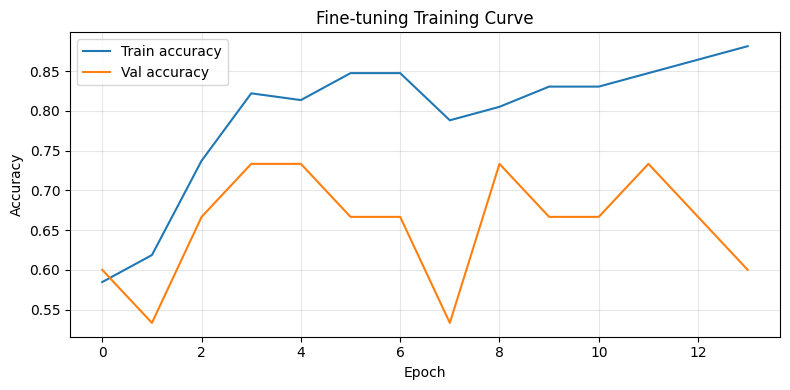

Saved finetune_curve.png


In [10]:
# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(train_accs, label='Train accuracy')
plt.plot(val_accs,   label='Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Fine-tuning Training Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/figures/finetune_curve.png', dpi=150)
plt.show()
print('Saved finetune_curve.png')